# 🔬 PyCupFM — Panel Cointegration with Common Factors

**Author:** Dr. Merwan Roudane ([merwanroudane920@gmail.com](mailto:merwanroudane920@gmail.com))  
**GitHub:** [github.com/merwanroudane/cupfm](https://github.com/merwanroudane/cupfm)  
**Version:** 1.0.0

---

This notebook demonstrates the full capabilities of `pycupfm`, the Python implementation of all 5 panel cointegration estimators from:

- **Bai, J., Kao, C. & Ng, S. (2009)**. *Panel cointegration with global stochastic trends*. Journal of Econometrics, 149(1), 82-99.
- **Bai, J. & Kao, C. (2005)**. *On the estimation and inference of a panel cointegration model with cross-sectional dependence*. SSRN-1815227.

### Estimators Implemented

| Estimator | Method | Recommended |
|-----------|--------|:---:|
| LSDV | Within/Fixed-effects | ❌ (biased) |
| Bai FM | Two-step Fully Modified | |
| **CupFM** | Continuously-Updated FM | ⭐ |
| CupFM-bar | CupFM with Z-bar | |
| CupBC | Continuously-Updated BC | |

In [1]:
# Install if needed
# !pip install pycupfm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pycupfm import CupFM, simulate_panel, monte_carlo
from pycupfm.datasets import load_grunfeld
from pycupfm.plotting import (
    plot_coefficients, plot_factors, plot_loadings,
    plot_convergence, plot_omega_heatmap, plot_factor_ic,
    plot_loadings_heatmap
)
from pycupfm.factors import bai_ng_ic

print('PyCupFM loaded successfully!')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')

PyCupFM loaded successfully!
NumPy: 1.26.4, Pandas: 2.2.0


---
## 1. 📊 Real Data Application — Grunfeld Investment Dataset

The classic Grunfeld (1958) dataset: **N = 10 firms, T = 20 years (1935–1954)**.

Model: $\ln(\text{invest})_{it} = \alpha_i + \beta_1 \ln(\text{mvalue})_{it} + \beta_2 \ln(\text{kstock})_{it} + \lambda_i' F_t + u_{it}$

In [2]:
# Load the Grunfeld dataset
df = load_grunfeld()
print(f'Dataset: {len(df)} observations')
print(f'Firms: {df["firm"].nunique()}, Years: {df["year"].nunique()}')
print(f'Variables: {list(df.columns)}')
df.head(10)

Dataset: 200 observations
Firms: 10, Years: 20
Variables: ['firm', 'firm_name', 'year', 'invest', 'mvalue', 'kstock', 'linvest', 'lmvalue', 'lkstock']


,firm,firm_name,year,invest,mvalue,kstock,linvest,lmvalue,lkstock
0,1,GM,1935,317.6,3078.5,2.8,5.760793,8.032198,1.029619
1,1,GM,1936,391.8,4661.7,52.6,5.970752,8.447135,3.962716
2,1,GM,1937,410.6,5387.1,156.9,6.017620,8.591762,5.055609
3,1,GM,1938,257.7,2792.2,209.2,5.551796,7.934585,5.343291
4,1,GM,1939,330.8,4313.2,203.4,5.801514,8.369435,5.315174
5,1,GM,1940,461.2,4643.9,207.2,6.133832,8.443310,5.333685
6,1,GM,1941,512.0,4551.2,255.2,6.238325,8.423146,5.542048
7,1,GM,1942,448.0,3244.1,303.7,6.104793,8.084593,5.716040
8,1,GM,1943,499.6,4053.7,264.1,6.213808,8.307385,5.576328
9,1,GM,1944,568.9,4379.3,201.6,6.343705,8.384644,5.306286


In [3]:
# Descriptive statistics
print('\n=== Descriptive Statistics ===')
df[['linvest', 'lmvalue', 'lkstock']].describe().round(4)


=== Descriptive Statistics ===


,linvest,lmvalue,lkstock
count,200.0000,200.0000,200.0000
mean,3.5509,6.3428,3.7811
std,1.9253,1.3810,1.9985
min,-0.9676,3.6687,-2.3026
25%,1.7924,5.2942,2.3702
50%,3.8411,6.3732,3.9080
75%,5.3293,7.5012,5.6716
max,6.6206,8.7340,6.9695


### 1.1 Fit CupFM with 1 Common Factor

In [4]:
# Create the CupFM model
model = CupFM(
    n_factors=1,          # 1 common factor
    bandwidth=3,          # Bartlett kernel bandwidth (suitable for T=20)
    kernel='bartlett',    # Bartlett kernel
    max_iter=25,          # Max CupFM/CupBC iterations
)

# Fit all 5 estimators
results = model.fit(
    y=df['linvest'],
    X=df[['lmvalue', 'lkstock']],
    panel_id=df['firm'],
    time_id=df['year'],
    var_names=['lmvalue', 'lkstock'],
    dep_var='linvest'
)

# Print publication-quality summary
results.summary()


  cupfm — Panel Cointegration with Common Factors        v1.0.0
  Bai, Kao & Ng (2009, JoE 149:82-99)  |  Bai & Kao (2005, SSRN-1815227)

  Panel Information
  --------------------------------------------------------------------------
  Dependent variable     : linvest         Regressors         : lmvalue, lkstock
  Cross-sections (N)     : 10              Time periods (T)   : 20
  Observations (N×T)     : 200             Panel type         : Balanced
  Common factors (r)     : 1               Bandwidth (M)      : 3 (bartlett)
  Max iterations         : 25              CupFM iterations   : 25
  --------------------------------------------------------------------------

  Estimation Results
  --------------------------------------------------------------------------
      Variable  |       LSDV     Bai FM      CupFM  CupFM-bar      CupBC
  --------------+----------------------------------------------------------
       lmvalue  |  0.5224***  0.5840***  0.7421***  0.6952***  0.5824***
 

'\n==============================================================================\n  cupfm — Panel Cointegration with Common Factors        v1.0.0\n  Bai, Kao & Ng (2009, JoE 149:82-99)  |  Bai & Kao (2005, SSRN-1815227)\n==============================================================================\n\n  Panel Information\n  --------------------------------------------------------------------------\n  Dependent variable     : linvest         Regressors         : lmvalue, lkstock\n  Cross-sections (N)     : 10              Time periods (T)   : 20\n  Observations (N×T)     : 200             Panel type         : Balanced\n  Common factors (r)     : 1               Bandwidth (M)      : 3 (bartlett)\n  Max iterations         : 25              CupFM iterations   : 25\n  --------------------------------------------------------------------------\n\n  Estimation Results\n  --------------------------------------------------------------------------\n      Variable  |       LSDV     Bai FM      Cu

### 1.2 Results as DataFrame

In [5]:
# Convert to pandas DataFrame for further analysis
results_df = results.to_dataframe()
results_df.round(4)

,Variable,Estimator,Coefficient,Std.Error,t-statistic,p-value,CI_lower,CI_upper
0,lmvalue,LSDV,0.5224,0.0767,6.8135,0.0000,0.3721,0.6727
1,lkstock,LSDV,0.0827,0.0247,3.3495,0.0008,0.0343,0.1311
2,lmvalue,Bai FM,0.5840,0.0512,11.4135,0.0000,0.4837,0.6842
3,lkstock,Bai FM,0.0789,0.0270,2.9203,0.0035,0.0259,0.1318
4,lmvalue,CupFM,0.7421,0.0711,10.4318,0.0000,0.6026,0.8815
5,lkstock,CupFM,0.0664,0.0283,2.3429,0.0191,0.0108,0.1219
6,lmvalue,CupFM-bar,0.6952,0.0918,7.5772,0.0000,0.5154,0.8751
7,lkstock,CupFM-bar,0.0716,0.0382,1.8713,0.0613,-0.0034,0.1465
8,lmvalue,CupBC,0.5824,0.0512,11.3794,0.0000,0.4821,0.6827
9,lkstock,CupBC,0.0791,0.0270,2.9274,0.0034,0.0261,0.1320


---
## 2. 🎨 Publication-Quality Visualizations

### 2.1 Coefficient Comparison Forest Plot

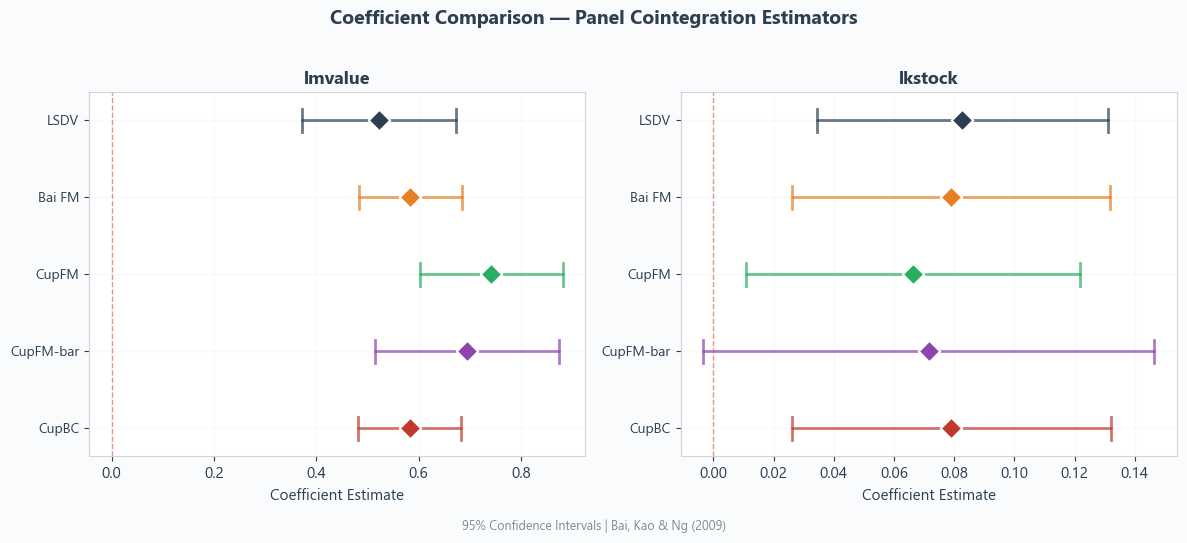

In [6]:
fig = plot_coefficients(results, figsize=(12, 5))
plt.show()

### 2.2 Estimated Common Factors

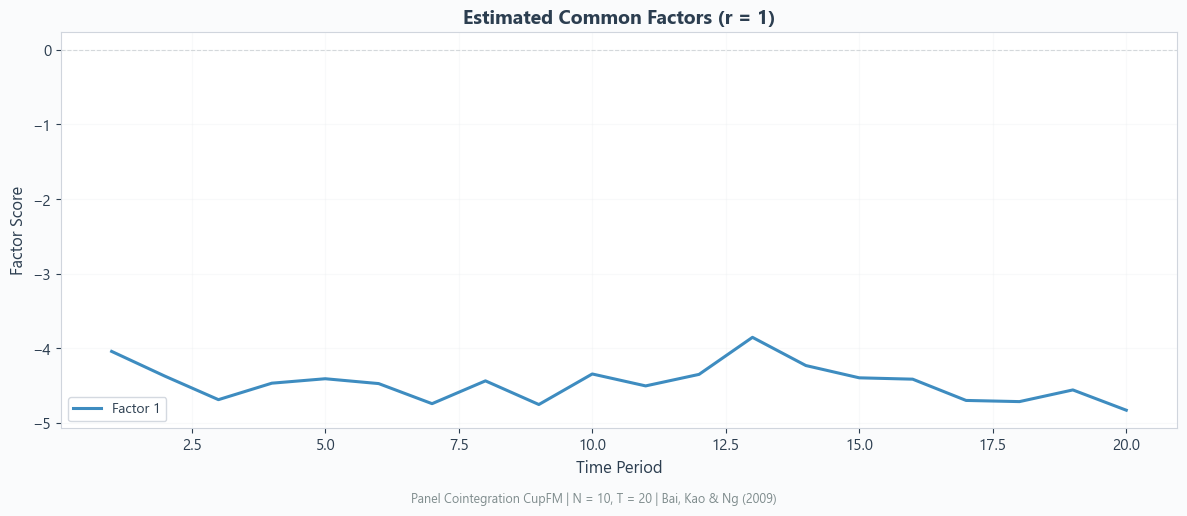

In [7]:
fig = plot_factors(results, figsize=(12, 5))
plt.show()

### 2.3 Factor Loadings

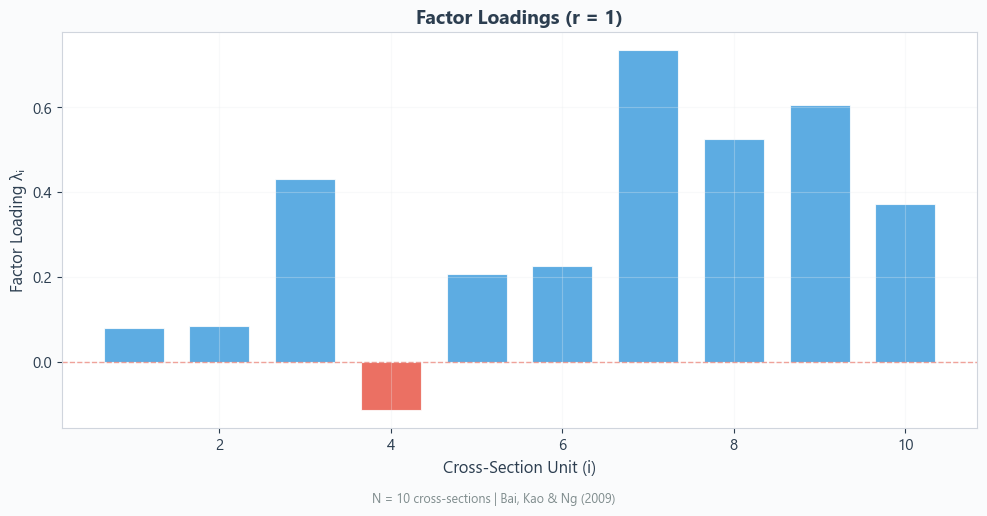

In [8]:
fig = plot_loadings(results, figsize=(10, 5))
plt.show()

### 2.4 CupFM Convergence Path

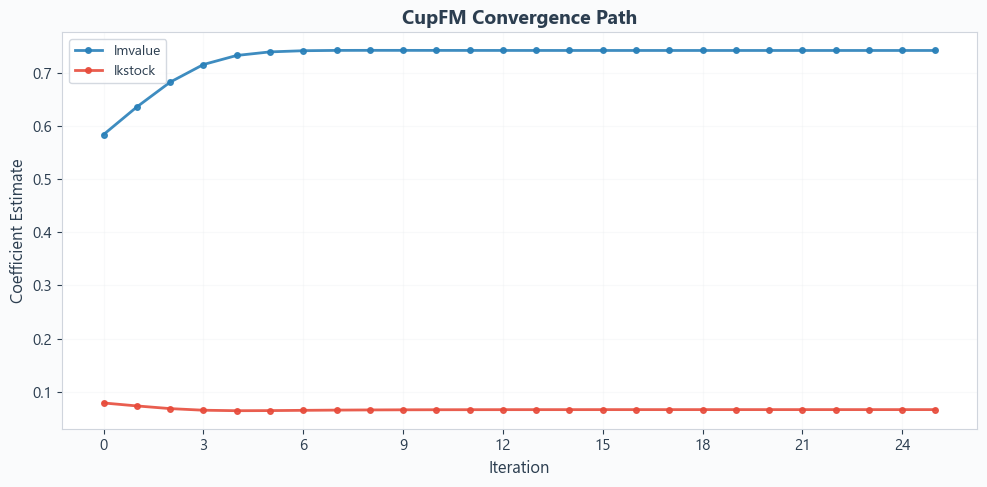

In [9]:
fig = plot_convergence(results, figsize=(10, 5))
plt.show()

### 2.5 Long-Run Covariance Ω Heatmap

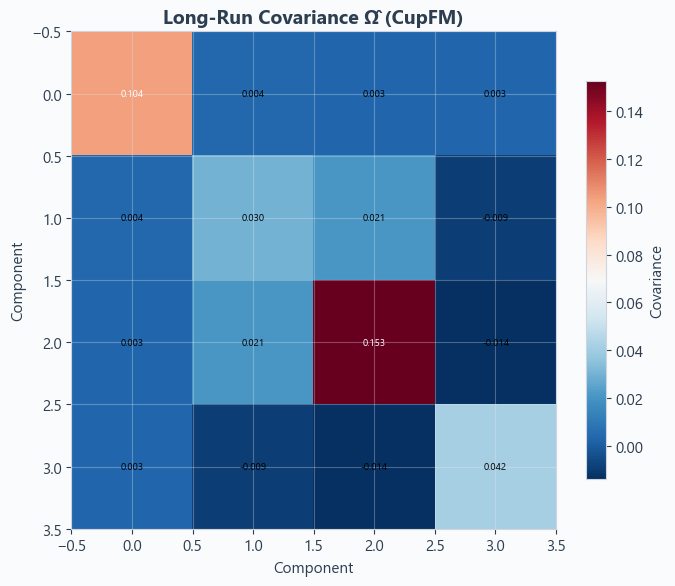

In [10]:
fig = plot_omega_heatmap(results, figsize=(7, 6))
plt.show()

### 2.6 Factor Loadings Heatmap

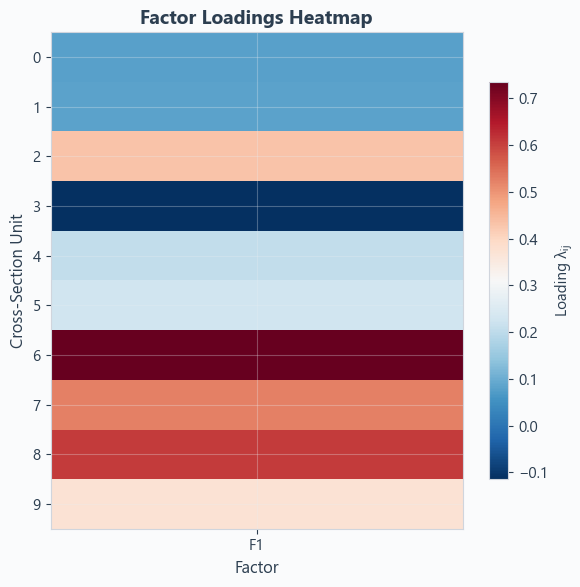

In [11]:
fig = plot_loadings_heatmap(results, figsize=(6, 6))
plt.show()

---
## 3. 🔍 Automatic Factor Selection (Bai & Ng 2002)

In [12]:
# Auto-select number of factors
model_auto = CupFM(n_factors='auto', bandwidth=3, auto_rmax=5, verbose=True)
results_auto = model_auto.fit(
    y=df['linvest'],
    X=df[['lmvalue', 'lkstock']],
    panel_id=df['firm'],
    time_id=df['year'],
    var_names=['lmvalue', 'lkstock'],
    dep_var='linvest'
)
print(f'\nAuto-selected r = {results_auto.r}')
results_auto.summary()

  Auto-selected r = 5 (Bai-Ng 2002 IC)
  Running CupFM: N=10, T=20, k=2, r=5, bw=3
CupFM iter 1: beta = [0.68438346 0.02039306]
CupFM iter 2: beta = [0.73581643 0.01521043]
CupFM iter 3: beta = [0.78780348 0.01486777]
CupFM iter 4: beta = [0.83508976 0.01918479]
CupFM iter 5: beta = [0.87140332 0.02529997]
CupFM iter 6: beta = [0.89467275 0.03086185]
CupFM iter 7: beta = [0.90762119 0.03504647]
CupFM iter 8: beta = [0.91423    0.03790139]
CupFM iter 9: beta = [0.91744851 0.039746  ]
CupFM iter 10: beta = [0.91897727 0.04090029]
CupFM iter 11: beta = [0.91969315 0.04160828]
CupFM iter 12: beta = [0.92002524 0.04203684]
CupFM iter 13: beta = [0.92017811 0.04229386]
CupFM iter 14: beta = [0.92024794 0.04244699]
CupFM iter 15: beta = [0.92027956 0.04253777]
CupFM iter 16: beta = [0.92029372 0.04259138]
CupFM iter 17: beta = [0.92029997 0.04262295]
CupFM iter 18: beta = [0.92030268 0.0426415 ]
CupFM iter 19: beta = [0.92030382 0.04265238]
CupFM iter 20: beta = [0.92030427 0.04265876]
CupBC 

'\n==============================================================================\n  cupfm — Panel Cointegration with Common Factors        v1.0.0\n  Bai, Kao & Ng (2009, JoE 149:82-99)  |  Bai & Kao (2005, SSRN-1815227)\n==============================================================================\n\n  Panel Information\n  --------------------------------------------------------------------------\n  Dependent variable     : linvest         Regressors         : lmvalue, lkstock\n  Cross-sections (N)     : 10              Time periods (T)   : 20\n  Observations (N×T)     : 200             Panel type         : Balanced\n  Common factors (r)     : 5               Bandwidth (M)      : 3 (bartlett)\n  Max iterations         : 20              CupFM iterations   : 20\n  --------------------------------------------------------------------------\n\n  Estimation Results\n  --------------------------------------------------------------------------\n      Variable  |       LSDV     Bai FM      Cu

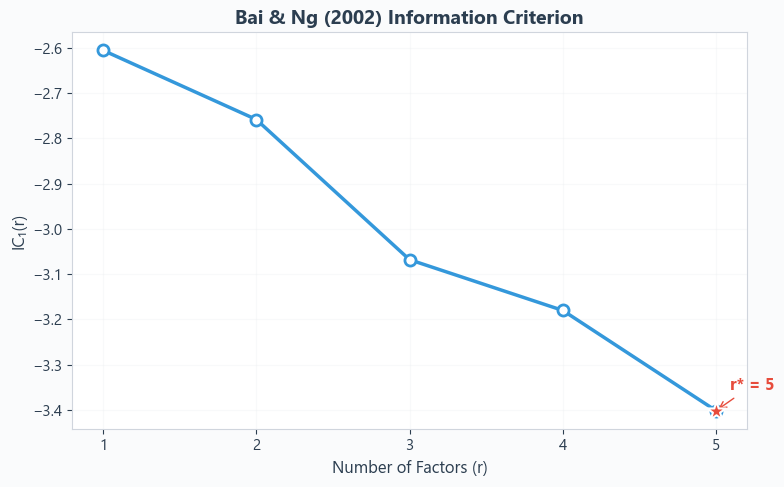

In [13]:
# Plot IC values
if model_auto.ic_values_ is not None:
    fig = plot_factor_ic(model_auto.ic_values_, figsize=(8, 5))
    plt.show()

---
## 4. 🧪 Monte Carlo Simulation (BKN 2009 DGP)

Replicate the simulation design from Bai, Kao & Ng (2009) Tables 1-4:
- $N = 20$, $T = 40$, $k = 1$, $r = 2$
- True $\beta = 2.0$
- AR(1) errors with $\rho = 0.3$
- Correlated $(u, v)$ innovations

In [14]:
# Simulate a single panel
sim = simulate_panel(N=20, T=40, k=1, r=2, beta=2.0, seed=42)
print(f'Simulated panel: N={20}, T={40}, true beta={2.0}')
print(f'Data shape: {sim["data"].shape}')
sim['data'].head()

Simulated panel: N=20, T=40, true beta=2.0
Data shape: (800, 4)


,panel_id,time_id,y,x1
0,1,1,30.187359,9.374597
1,1,2,29.774465,9.686056
2,1,3,32.183344,10.602527
3,1,4,32.843782,12.480413
4,1,5,32.188386,11.296916


In [15]:
# Fit CupFM on simulated data
model_sim = CupFM(n_factors=2, bandwidth=5, max_iter=20)
results_sim = model_sim.fit(
    y=sim['data']['y'],
    X=sim['data'][['x1']],
    panel_id=sim['data']['panel_id'],
    time_id=sim['data']['time_id'],
    var_names=['x1'],
    dep_var='y'
)
results_sim.summary()

print(f'\n  True beta  = {sim["beta_true"][0]:.4f}')
print(f'  CupFM bias = {results_sim.beta[0] - sim["beta_true"][0]:.4f}')
print(f'  LSDV  bias = {results_sim.betas["LSDV"][0] - sim["beta_true"][0]:.4f}')


  cupfm — Panel Cointegration with Common Factors        v1.0.0
  Bai, Kao & Ng (2009, JoE 149:82-99)  |  Bai & Kao (2005, SSRN-1815227)

  Panel Information
  --------------------------------------------------------------------------
  Dependent variable     : y               Regressors         : x1
  Cross-sections (N)     : 20              Time periods (T)   : 40
  Observations (N×T)     : 800             Panel type         : Balanced
  Common factors (r)     : 2               Bandwidth (M)      : 5 (bartlett)
  Max iterations         : 20              CupFM iterations   : 20
  --------------------------------------------------------------------------

  Estimation Results
  --------------------------------------------------------------------------
      Variable  |       LSDV     Bai FM      CupFM  CupFM-bar      CupBC
  --------------+----------------------------------------------------------
            x1  |  1.9046***  1.8837***  1.8400***  1.8718***  1.9676***
               



  True beta  = 2.0000
  CupFM bias = -0.1600
  LSDV  bias = -0.0954


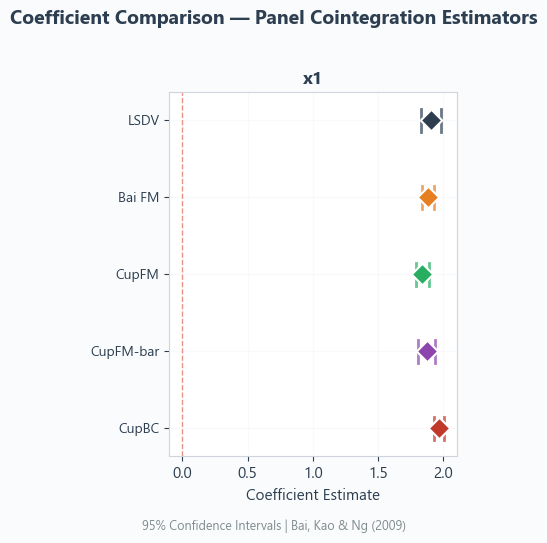

In [16]:
# Visualize simulated data results
fig = plot_coefficients(results_sim, figsize=(8, 5))
plt.show()

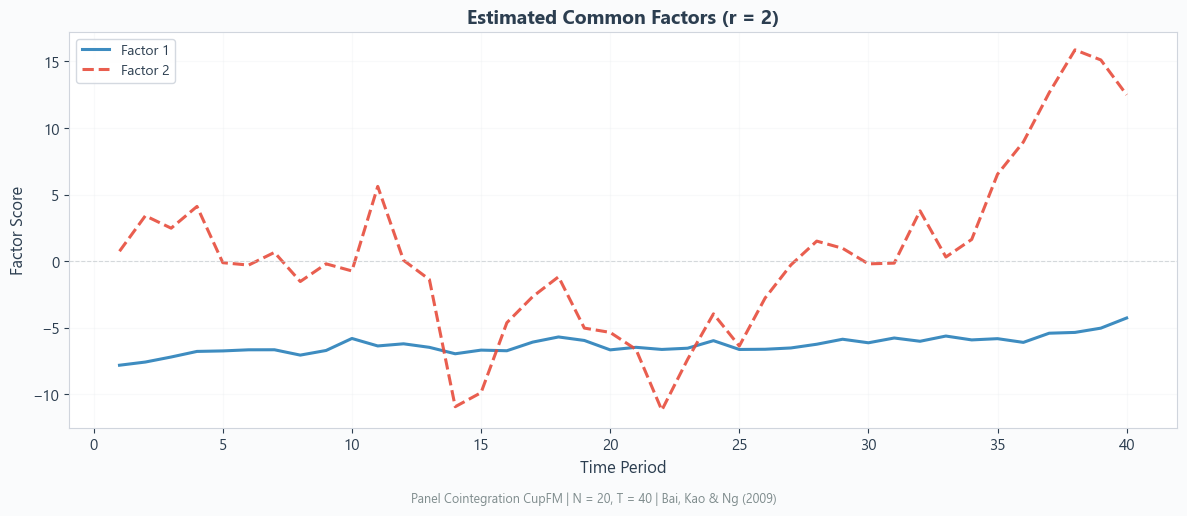

In [17]:
fig = plot_factors(results_sim, figsize=(12, 5))
plt.show()

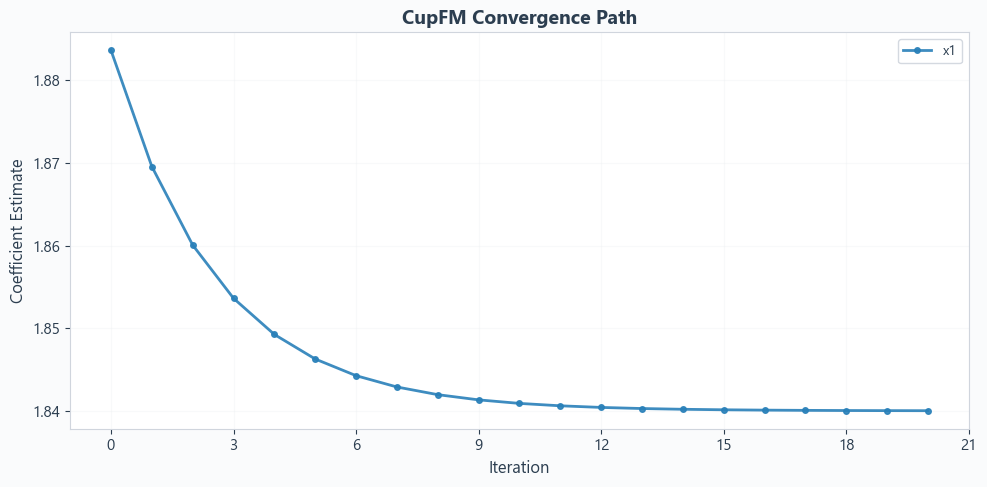

In [18]:
fig = plot_convergence(results_sim, figsize=(10, 5))
plt.show()

### 4.1 Monte Carlo Experiment (50 replications)

In [19]:
# Run Monte Carlo (use n_reps=500+ for publication; 50 for demo speed)
mc_results = monte_carlo(
    n_reps=50, N=20, T=40, k=1, r=2,
    beta=2.0, bandwidth=5, max_iter=20,
    seed=42, verbose=True
)

  MC replication 10/50


  MC replication 20/50


  MC replication 30/50


  MC replication 40/50


  MC replication 50/50

  Monte Carlo Summary:
               mean       std  count      RMSE
estimator                                     
Bai FM    -0.145633  0.072279     50  0.162262
CupBC     -0.138480  0.065283     50  0.152818
CupFM     -0.142139  0.063900     50  0.155580
CupFM-bar -0.140196  0.063059     50  0.153466
LSDV      -0.068856  0.197802     50  0.207567


In [20]:
# Summary statistics
mc_summary = mc_results.groupby('estimator').agg(
    Mean_Beta=('beta_hat', 'mean'),
    Mean_Bias=('bias', 'mean'),
    Std_Bias=('bias', 'std'),
    RMSE=('bias', lambda x: np.sqrt((x**2).mean())),
    N_reps=('rep', 'nunique')
).round(4)

# Reorder to match BKN paper
order = ['LSDV', 'Bai FM', 'CupFM', 'CupFM-bar', 'CupBC']
mc_summary = mc_summary.loc[[e for e in order if e in mc_summary.index]]
print('\n=== Monte Carlo Results (BKN 2009 DGP) ===')
print(f'True β = 2.0, N=20, T=40, r=2, {mc_results["rep"].nunique()} reps\n')
mc_summary


=== Monte Carlo Results (BKN 2009 DGP) ===
True β = 2.0, N=20, T=40, r=2, 50 reps



,Mean_Beta,Mean_Bias,Std_Bias,RMSE,N_reps
estimator,,,,,
LSDV,1.9311,-0.0689,0.1978,0.2076,50
Bai FM,1.8544,-0.1456,0.0723,0.1623,50
CupFM,1.8579,-0.1421,0.0639,0.1556,50
CupFM-bar,1.8598,-0.1402,0.0631,0.1535,50
CupBC,1.8615,-0.1385,0.0653,0.1528,50


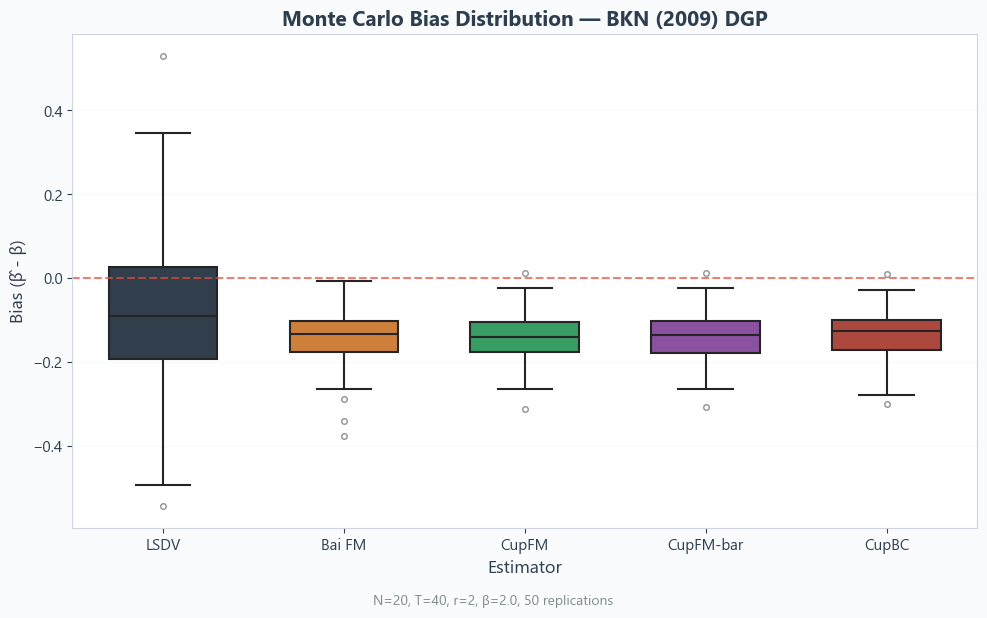

In [21]:
# Beautiful MC bias boxplot
import seaborn as sns
from pycupfm.plotting import _setup_style, COLORS

_setup_style()
fig, ax = plt.subplots(figsize=(10, 6))

palette = [COLORS.get(e, '#999') for e in order if e in mc_results['estimator'].unique()]
sns.boxplot(
    data=mc_results, x='estimator', y='bias',
    order=[e for e in order if e in mc_results['estimator'].unique()],
    palette=palette, width=0.6, linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5},
    ax=ax
)
ax.axhline(y=0, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Estimator', fontsize=13)
ax.set_ylabel('Bias (β̂ - β)', fontsize=13)
ax.set_title('Monte Carlo Bias Distribution — BKN (2009) DGP',
             fontsize=15, fontweight='bold')
fig.text(0.5, -0.02, f'N=20, T=40, r=2, β=2.0, {mc_results["rep"].nunique()} replications',
         ha='center', fontsize=10, color='#7F8C8D')
plt.tight_layout()
plt.show()

---
## 5. 🔧 Bandwidth Sensitivity Analysis

In [22]:
# Test robustness across bandwidth values
bw_values = [2, 3, 4, 5, 6, 8]
bw_results = []

for bw in bw_values:
    m = CupFM(n_factors=1, bandwidth=bw, max_iter=25)
    r = m.fit(y=df['linvest'], X=df[['lmvalue', 'lkstock']],
              panel_id=df['firm'], time_id=df['year'],
              var_names=['lmvalue', 'lkstock'])
    for j, vn in enumerate(['lmvalue', 'lkstock']):
        bw_results.append({
            'Bandwidth': bw,
            'Variable': vn,
            'CupFM': r.betas['CupFM'][j],
            'CupBC': r.betas['CupBC'][j],
            'Bai FM': r.betas['Bai FM'][j],
        })

bw_df = pd.DataFrame(bw_results)
print('\n=== Bandwidth Sensitivity ===')
bw_df.round(4)


=== Bandwidth Sensitivity ===


,Bandwidth,Variable,CupFM,CupBC,Bai FM
0,2,lmvalue,0.7751,0.5586,0.5602
1,2,lkstock,0.0796,0.0888,0.0885
2,3,lmvalue,0.7421,0.5824,0.5840
3,3,lkstock,0.0664,0.0791,0.0789
4,4,lmvalue,0.7720,0.6608,0.6625
5,4,lkstock,0.0546,0.0619,0.0618
6,5,lmvalue,0.7931,0.7505,0.7521
7,5,lkstock,0.0393,0.0440,0.0440
8,6,lmvalue,0.8090,0.7976,0.7986
9,6,lkstock,0.0215,0.0323,0.0324


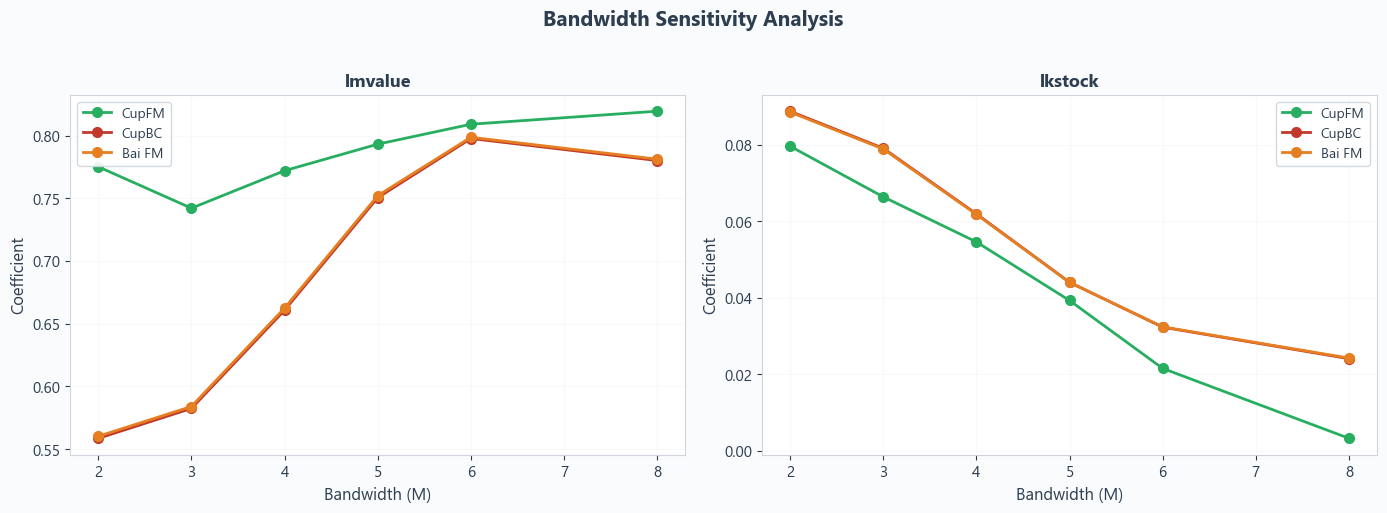

In [23]:
# Bandwidth sensitivity plot
_setup_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, var in enumerate(['lmvalue', 'lkstock']):
    ax = axes[idx]
    subset = bw_df[bw_df['Variable'] == var]
    for est, color in [('CupFM', '#27AE60'), ('CupBC', '#C0392B'), ('Bai FM', '#E67E22')]:
        ax.plot(subset['Bandwidth'], subset[est], marker='o', linewidth=2,
                color=color, label=est, markersize=7)
    ax.set_xlabel('Bandwidth (M)', fontsize=12)
    ax.set_ylabel('Coefficient', fontsize=12)
    ax.set_title(f'{var}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle('Bandwidth Sensitivity Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. 📤 Export Results

In [24]:
# LaTeX table
latex = results.to_latex(caption='CupFM Panel Cointegration — Grunfeld Data')
print(latex)

\begin{table}[htbp]
  \centering\small
  \caption{CupFM Panel Cointegration — Grunfeld Data}
  \label{tab:cupfm}
  \begin{tabular}{l*{5}{c}}
    \hline\hline
    & LSDV & Bai FM & CupFM & CupFM-bar & CupBC \\
    \hline
    lmvalue & $0.5224^{***}$ & $0.5840^{***}$ & $0.7421^{***}$ & $0.6952^{***}$ & $0.5824^{***}$ \\
     & (6.814) & (11.413) & (10.432) & (7.577) & (11.379) \\
    lkstock & $0.0827^{***}$ & $0.0789^{***}$ & $0.0664^{**}$ & $0.0716^{*}$ & $0.0791^{***}$ \\
     & (3.350) & (2.920) & (2.343) & (1.871) & (2.927) \\
    \hline
    N (units) & \multicolumn{5}{c}{10} \\
    T (periods) & \multicolumn{5}{c}{20} \\
    r (factors) & \multicolumn{5}{c}{1} \\
    \hline\hline
  \end{tabular}
\end{table}


In [25]:
# Export to all formats
from pycupfm import export_results
export_results(results, 'cupfm_grunfeld', fmt='all')
print('Exported: cupfm_grunfeld.csv, .xlsx, .tex, .html')

Exported: cupfm_grunfeld.csv, .xlsx, .tex, .html


---
## 7. 📚 Summary

This notebook demonstrated:

1. **Real data application** with the Grunfeld dataset (N=10, T=20)
2. **All 5 estimators** (LSDV, Bai FM, CupFM, CupFM-bar, CupBC)
3. **6 visualization types** (coefficients, factors, loadings, convergence, Ω heatmap, loadings heatmap)
4. **Automatic factor selection** via Bai-Ng (2002) IC
5. **Monte Carlo simulation** replicating BKN (2009) DGP
6. **Bandwidth sensitivity** robustness check
7. **Export** to LaTeX, Excel, CSV, and HTML

### References

- Bai, J., Kao, C. & Ng, S. (2009). *Panel cointegration with global stochastic trends*. JoE 149(1), 82-99.
- Bai, J. & Kao, C. (2005). SSRN-1815227.
- Bai, J. & Ng, S. (2002). *Econometrica* 70(1), 191-221.

**Author:** Dr. Merwan Roudane — [merwanroudane920@gmail.com](mailto:merwanroudane920@gmail.com)